# Testando um modelo simples de aprendizado de um Datase aleatório

## Imports

In [61]:
import IPython.display as ipd
import json
import numpy as np
import matplotlib.pyplot as plt
import random
import soundfile as sf
import pandas as pd

from fm_synth import FMSynth, SAMPLE_RATE


## Gerando um dataset aleatório

### Rodando aleatoriamente e salvando o resultado

In [62]:
duracao_amostras = 4
tamanho_dataset = 1000
precisao_decimal = 3

In [63]:
# with open("dataset/parameters.json", "w") as f:
#     f.write("[\n")
#     for i in range(tamanho_dataset):
#         # Sorteando uma frequencia báse, na faixa audível humana
#         frequencia_base = random.random() * 20000 + 20
#         frequencia_base = round(frequencia_base, precisao_decimal)

#         # Sorteando os demais parâmetros da síntese
#         amplitude1 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         frequency1 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         beta2 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         amplitude2 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         frequency2 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         beta3 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         amplitude3 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         frequency3 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         beta4 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         amplitude4 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         frequency4 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         beta5 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         amplitude5 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         frequency5 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         beta_carrier = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         amplitude_carrier = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         attack = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         decay = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         sustain = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         release = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         if decay <= 0:
#             print(decay)

#         # Guardando os parâmetros em JSON
#         data = {
#             "id": i,
#             "frequencia_base": frequencia_base,
#             "amplitude1": amplitude1,
#             "frequency1": frequency1,
#             "beta2": beta2,
#             "amplitude2": amplitude2,
#             "frequency2": frequency2,
#             "beta3": beta3,
#             "amplitude3": amplitude3,
#             "frequency3": frequency3,
#             "beta4": beta4,
#             "amplitude4": amplitude4,
#             "frequency4": frequency4,
#             "beta5": beta5,
#             "amplitude5": amplitude5,
#             "frequency5": frequency5,
#             "beta_carrier": beta_carrier,
#             "amplitude_carrier": amplitude_carrier,
#             "attack": attack,
#             "decay": decay,
#             "sustain": sustain,
#             "release": release,
#         }

#         # Codificando os parâmetros em json
#         data = json.dumps(data)

#         # Imprimindo na saída
#         f.write(data)
#         if (i<tamanho_dataset-1):
#             f.write(",\n")
#         else:
#             f.write("\n")

#         # Sintetizando o sinal
#         fm_synth = FMSynth(
#             amplitude1=amplitude1,
#             frequency1=frequency1,
#             beta2=beta2,
#             amplitude2=amplitude2,
#             frequency2=frequency2,
#             beta3=beta3,
#             amplitude3=amplitude3,
#             frequency3=frequency3,
#             beta4=beta4,
#             amplitude4=amplitude4,
#             frequency4=frequency4,
#             beta5=beta5,
#             amplitude5=amplitude5,
#             frequency5=frequency5,
#             beta_carrier=beta_carrier,
#             amplitude_carrier=amplitude_carrier,
#             attack=attack,
#             decay=decay,
#             sustain=sustain,
#             release=release,
#         )
#         signal = fm_synth.synth_alg1(duracao_amostras, frequencia_base)
        
#         # Escrevendo o áudio em arquivo
#         sf.write(f"dataset/sample_{i}.wav", signal, SAMPLE_RATE)

#     f.write("]")

## Lendo o dataset no formato pandas

### Lendo as variáveis de entrada

In [64]:
samples = []
for i in range(tamanho_dataset):
    signal = sf.read(f"dataset/sample_{i}.wav")
    samples.append(signal)

samples = pd.DataFrame(samples)

In [65]:
samples = samples.drop(columns=[1])
samples.head()

,0
0,"[0.0, -6.103515625e-05, 6.103515625e-05, 3.051..."
1,"[0.0, -3.0517578125e-05, -3.0517578125e-05, 0...."
2,"[0.0, -6.103515625e-05, 9.1552734375e-05, 0.00..."
3,"[0.0, 0.0, 3.0517578125e-05, 9.1552734375e-05,..."
4,"[0.0, 0.0, 0.0, 0.0, -3.0517578125e-05, -3.051..."


### Lendo o alvo

In [66]:
with open("dataset/parameters.json", "r") as f:
    target = f.read()

target = json.loads(target)
target = target[:tamanho_dataset]

target = pd.DataFrame(target)
target.head()

,id,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,0,15061.183,0.524,0.477,0.344,0.765,0.549,0.811,0.439,0.183,...,0.787,0.739,0.120,0.204,0.147,0.312,0.287,0.127,0.726,0.848
1,1,16951.022,0.082,0.350,0.035,0.879,0.471,0.787,0.275,0.393,...,0.697,0.788,0.960,0.593,0.192,0.038,0.701,0.450,0.404,0.560
2,2,15429.197,0.736,0.356,0.461,0.279,0.581,0.204,0.291,0.803,...,0.058,0.346,0.573,0.535,0.972,0.612,0.492,0.038,0.472,0.142
3,3,1051.543,0.898,0.537,0.633,0.708,0.926,0.369,0.107,0.342,...,0.800,0.849,0.108,0.993,0.133,0.337,0.362,0.150,0.629,0.580
4,4,2842.837,0.879,0.063,0.835,0.561,0.806,0.412,0.605,0.589,...,0.528,0.018,0.923,0.378,0.290,0.092,0.882,0.899,0.674,0.224


In [67]:
target = target.drop(columns=["id"])
target.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,15061.183,0.524,0.477,0.344,0.765,0.549,0.811,0.439,0.183,0.289,...,0.787,0.739,0.120,0.204,0.147,0.312,0.287,0.127,0.726,0.848
1,16951.022,0.082,0.350,0.035,0.879,0.471,0.787,0.275,0.393,0.079,...,0.697,0.788,0.960,0.593,0.192,0.038,0.701,0.450,0.404,0.560
2,15429.197,0.736,0.356,0.461,0.279,0.581,0.204,0.291,0.803,0.414,...,0.058,0.346,0.573,0.535,0.972,0.612,0.492,0.038,0.472,0.142
3,1051.543,0.898,0.537,0.633,0.708,0.926,0.369,0.107,0.342,0.733,...,0.800,0.849,0.108,0.993,0.133,0.337,0.362,0.150,0.629,0.580
4,2842.837,0.879,0.063,0.835,0.561,0.806,0.412,0.605,0.589,0.155,...,0.528,0.018,0.923,0.378,0.290,0.092,0.882,0.899,0.674,0.224


### Juntando alvo e features

In [68]:
ds = pd.concat([samples, target], axis=1)
ds.head()

,0,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,"[0.0, -6.103515625e-05, 6.103515625e-05, 3.051...",15061.183,0.524,0.477,0.344,0.765,0.549,0.811,0.439,0.183,...,0.787,0.739,0.120,0.204,0.147,0.312,0.287,0.127,0.726,0.848
1,"[0.0, -3.0517578125e-05, -3.0517578125e-05, 0....",16951.022,0.082,0.350,0.035,0.879,0.471,0.787,0.275,0.393,...,0.697,0.788,0.960,0.593,0.192,0.038,0.701,0.450,0.404,0.560
2,"[0.0, -6.103515625e-05, 9.1552734375e-05, 0.00...",15429.197,0.736,0.356,0.461,0.279,0.581,0.204,0.291,0.803,...,0.058,0.346,0.573,0.535,0.972,0.612,0.492,0.038,0.472,0.142
3,"[0.0, 0.0, 3.0517578125e-05, 9.1552734375e-05,...",1051.543,0.898,0.537,0.633,0.708,0.926,0.369,0.107,0.342,...,0.800,0.849,0.108,0.993,0.133,0.337,0.362,0.150,0.629,0.580
4,"[0.0, 0.0, 0.0, 0.0, -3.0517578125e-05, -3.051...",2842.837,0.879,0.063,0.835,0.561,0.806,0.412,0.605,0.589,...,0.528,0.018,0.923,0.378,0.290,0.092,0.882,0.899,0.674,0.224


In [69]:
ds.shape

(1000, 22)

## Separando treino e teste

In [70]:
train = ds.sample(frac=0.75, random_state=0)
test = ds.drop(train.index)

In [71]:
train.head(5)

,0,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
993,"[0.0, 3.0517578125e-05, -0.00018310546875, 0.0...",8817.278,0.978,0.489,0.501,0.007,0.126,0.196,0.862,0.461,...,0.381,0.931,0.071,0.235,0.166,0.853,0.441,0.810,0.005,0.430
859,"[0.0, -3.0517578125e-05, -9.1552734375e-05, -6...",19392.466,0.514,0.720,0.865,0.681,0.650,0.282,0.877,0.992,...,0.565,0.330,0.973,0.234,0.708,0.891,0.996,0.504,0.526,0.840
298,"[0.0, 3.0517578125e-05, 6.103515625e-05, -0.00...",4415.950,0.867,0.971,0.216,0.636,0.788,0.085,0.890,0.498,...,0.911,0.921,0.125,0.463,0.464,0.766,0.578,0.664,0.177,0.634
553,"[0.0, 6.103515625e-05, -3.0517578125e-05, -0.0...",5680.907,0.125,0.696,0.770,0.044,0.480,0.299,0.797,0.708,...,0.084,0.451,0.871,0.987,0.038,0.886,0.508,0.090,0.869,0.467
672,"[0.0, 3.0517578125e-05, -0.0001220703125, 9.15...",8129.444,0.047,0.667,0.831,0.748,0.640,0.172,0.429,0.501,...,0.893,0.343,0.940,0.310,0.110,0.298,0.250,0.279,0.257,0.068


In [72]:
x = pd.DataFrame(train[0])
print(x.head())

x_t = pd.DataFrame(test[0])
print(x_t.head())

                                                     0
993  [0.0, 3.0517578125e-05, -0.00018310546875, 0.0...
859  [0.0, -3.0517578125e-05, -9.1552734375e-05, -6...
298  [0.0, 3.0517578125e-05, 6.103515625e-05, -0.00...
553  [0.0, 6.103515625e-05, -3.0517578125e-05, -0.0...
672  [0.0, 3.0517578125e-05, -0.0001220703125, 9.15...
                                                    0
9   [0.0, 3.0517578125e-05, 6.103515625e-05, -6.10...
11  [0.0, -3.0517578125e-05, 0.0, 0.0, 3.051757812...
19  [0.0, -0.000152587890625, -9.1552734375e-05, 0...
23  [0.0, -0.000244140625, -3.0517578125e-05, 0.00...
24  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...


In [73]:
x = np.array(x[0].values.tolist())
print(x[0])

x_t = np.array(x_t[0].values.tolist())
print(x_t[0])

[ 0.00000000e+00  3.05175781e-05 -1.83105469e-04 ... -3.05175781e-05
  0.00000000e+00 -3.05175781e-05]
[0.00000000e+00 3.05175781e-05 6.10351562e-05 ... 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


In [74]:
len(x[0])

88200

In [75]:
y = train.drop(columns=[0])
print(y.head())

y_t = test.drop(columns=[0])
print(y_t.head())

     frequencia_base  amplitude1  frequency1  beta2  amplitude2  frequency2  \
993         8817.278       0.978       0.489  0.501       0.007       0.126   
859        19392.466       0.514       0.720  0.865       0.681       0.650   
298         4415.950       0.867       0.971  0.216       0.636       0.788   
553         5680.907       0.125       0.696  0.770       0.044       0.480   
672         8129.444       0.047       0.667  0.831       0.748       0.640   

     beta3  amplitude3  frequency3  beta4  ...  frequency4  beta5  amplitude5  \
993  0.196       0.862       0.461  0.633  ...       0.381  0.931       0.071   
859  0.282       0.877       0.992  0.890  ...       0.565  0.330       0.973   
298  0.085       0.890       0.498  0.188  ...       0.911  0.921       0.125   
553  0.299       0.797       0.708  0.627  ...       0.084  0.451       0.871   
672  0.172       0.429       0.501  0.348  ...       0.893  0.343       0.940   

     frequency5  beta_carrier  amplitu

### Quebrando a entrada em frames

In [76]:
def to_frames(x, frame_length = 2048):
  dataset = []
  for sample in x:
    length = sample.shape[0]
    num_frames = int(length / frame_length)
    amostras_uteis = num_frames * frame_length
    sample_cutted = sample[:amostras_uteis]
    sample_cutted = sample_cutted.reshape(num_frames, frame_length)
    dataset.append(sample_cutted)

  return np.array(dataset)
  # print(x.shape)
  # x[0:5]

x = to_frames(x)
x_t = to_frames(x_t)

### Escrevendo o dados em arquivos

In [77]:
np.save("x.npy", x)
np.save("x_t.npy", x_t)

In [78]:
y.to_csv("y.csv")
y_t.to_csv("y_t.csv")

## Construindo o modelo

### Iniciando o MLFlow

In [19]:
import mlflow
mlflow.set_tracking_uri(uri="http://127.0.0.1:5000")
mlflow.set_experiment("fmsynth_model_test")
mlflow.start_run()

<ActiveRun: >

In [20]:
from keras.layers import TimeDistributed, Dense, Input, Lambda, BatchNormalization, Concatenate, Conv1D, ZeroPadding1D
from keras.models import Model
from tensorflow.keras.utils import plot_model
from keras.callbacks import EarlyStopping
import tensorflow as tf

2024-11-03 21:50:03.663683: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-03 21:50:03.815342: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1730681403.888819    9550 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1730681403.909183    9550 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-03 21:50:04.076018: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [21]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [22]:
# Configurando para não alocar diretamente toda a memória da GPU (alocar conforme necessário)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Aloca memória conforme necessário
    except RuntimeError as e:
        print(e)

In [23]:
def extrator_features(input_dims, activation, bias, dropout, kernel_regularizer):
  input_layer = Input(shape=[input_dims])

  x_0 = Dense(int(input_dims), activation=activation, use_bias=bias, kernel_regularizer=kernel_regularizer)(input_layer)

  if dropout:
    x_1 = tf.keras.layers.Dropout(0.2)(x_0)
  else:
    x_1 = x_0

  x_2 = Dense(int(input_dims/4), activation=activation, use_bias=bias, kernel_regularizer=kernel_regularizer)(x_1)
  x_3 = Dense(int(input_dims/8), activation=activation, use_bias=bias, kernel_regularizer=kernel_regularizer)(x_2)
  x_bottleneck = Dense(int(input_dims/16), activation=activation, name='encoder', use_bias=bias, kernel_regularizer=kernel_regularizer)(x_3)

  return Model(input_layer, x_bottleneck, name="features")

def regressor(input_dims, output_dims, activation, bias, kernel_regularizer):
  input_layer = Input(shape=[input_dims])

  x_0 = Dense(int(input_dims/2), activation=activation, use_bias=bias, kernel_regularizer=kernel_regularizer)(input_layer)
  x_2 = Dense(int(input_dims/4), activation=activation, use_bias=bias, kernel_regularizer=kernel_regularizer)(x_0)
  saidas = Dense(output_dims, activation=activation, name='regressor_saidas', use_bias=bias, kernel_regularizer=kernel_regularizer)(x_2)

  return Model(input_layer, saidas, name="regressor")

def my_mean(x):
  return tf.reduce_mean(x, axis=1)

def my_max(x):
  return tf.reduce_max(x, axis=1)

def my_sum(x):
  return tf.reduce_sum(x, axis=1)

def my_min(x):
  return tf.reduce_min(x, axis=1)

def my_min(x):
  return tf.reduce_prod(x, axis=1)

def my_logsumexp(x):
  return tf.reduce_logsumexp(x, axis=1)

def my_prod(x):
  return tf.reduce_prod(x, axis=1)

def pooling_function(pooling_strategy):
  if pooling_strategy == 'mean':
    return my_mean
  elif pooling_strategy == 'max':
    return my_max
  elif pooling_strategy == 'sum':
    return my_sum
  elif pooling_strategy == 'min':
    return my_min
  elif pooling_strategy == 'logsumexp':
    return my_logsumexp
  elif pooling_strategy == 'prod':
    return my_prod
  else:
    raise Exception(f"Pooling not implemented: {pooling_strategy}")

def build_model(
  input_len: int,
  input_dims: int,
  output_dims: int,
  activation: str,
  bias: bool,
  kernel_regularizer: str,
  dropout: bool,
  pooling_strategy: str,
  normalization: bool,
  optimizer: str,
):
  # Camadas de entrada
  input_layer = Input(shape=(input_len, input_dims))

  if normalization:
    x_n = BatchNormalization()(input_layer)
  else:
    x_n = input_layer

  # Kernels
  extrator = extrator_features(input_dims, activation, bias, dropout, kernel_regularizer)

  # Features
  features = TimeDistributed(extrator, name="features_padrao")(x_n)

  # Juntando as features
  media_features = Lambda(pooling_function(pooling_strategy))(features)

  # Regressão
  regressao = regressor(media_features.shape[1], output_dims, activation, bias, kernel_regularizer)

  saida = regressao(media_features)

  model = Model(input_layer, saida, name="regressao")
  
  # return (
  #     Model(input_layer, saida, name="regressao"),
  #     Model(input_layer, media_features, name="projecao")
  # )

  # model, _ = build_models(input_len, input_dims, output_dims, activation, bias, kernel_regularizer, dropout, pooling_strategy, normalization)
  model.compile(optimizer=optimizer, loss='mse', metrics=['mae', 'mse', 'mean_absolute_percentage_error'])
  # plot_model(model, show_shapes=True, expand_nested=True)
  return model

In [66]:
def train_model(
  input_len: int, # x.shape[1]
  input_dims: int, # x.shape[2]
  output_dims: int, # y.shape[1]
  activation: str, # elu
  bias: bool, # False
  kernel_regularizer: str, # None
  dropout: bool, # True
  pooling_strategy: str, # mean
  normalization: bool, # True
  optimizer: str, # adamax        
):
    params = {
        input_len: input_len,
        input_dims: input_dims,
        output_dims: output_dims,
        activation: activation,
        bias: bias,
        kernel_regularizer: kernel_regularizer,
        dropout: dropout,
        pooling_strategy: pooling_strategy,
        normalization: normalization,
        optimizer: optimizer,
    }
    
    # Gravando os parâmetros usados
    mlflow.log_params(params)

    # Construindo o modelo
    model = build_model(**params)

    # Callback para recuperar o melhor peso, e parar quando ficar três épocas sem melhora
    callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)

    # Treinando o modelo
    return model.fit(x, y, epochs=30, validation_split = 0.2, callbacks=[callback])

Epoch 1/30


2024-10-28 14:52:57.572831: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'loop_select_fusion_1', 1328 bytes spill stores, 1328 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_select_fusion_2', 636 bytes spill stores, 636 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_select_fusion', 788 bytes spill stores, 788 bytes spill loads



18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 6473706.5000 - mae: 483.0685 - mean_absolute_percentage_error: 1006.0499 - mse: 6473706.5000

2024-10-28 14:53:12.428309: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'loop_select_fusion_1', 1328 bytes spill stores, 1328 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'loop_select_fusion', 788 bytes spill stores, 788 bytes spill loads



19/19 ━━━━━━━━━━━━━━━━━━━━ 37s 986ms/step - loss: 6448953.5000 - mae: 482.3765 - mean_absolute_percentage_error: 1157.5768 - mse: 6448953.5000 - val_loss: 6462352.0000 - val_mae: 492.1079 - val_mean_absolute_percentage_error: 2567.9824 - val_mse: 6462352.0000
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 6068147.5000 - mae: 496.0523 - mean_absolute_percentage_error: 22160.3555 - mse: 6068147.5000 - val_loss: 5555939.0000 - val_mae: 509.4004 - val_mean_absolute_percentage_error: 36961.9102 - val_mse: 5555939.0000
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 3555468.0000 - mae: 571.1964 - mean_absolute_percentage_error: 187228.9219 - mse: 3555468.0000 - val_loss: 2552165.0000 - val_mae: 467.5383 - val_mean_absolute_percentage_error: 98664.8438 - val_mse: 2552165.0000
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 1992401.3750 - mae: 445.1525 - mean_absolute_percentage_error: 159969.1250 - mse: 1992401.3750 - val_loss: 2049832.5000 - val_mae: 291.644

In [67]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,mean_absolute_percentage_error,mse,val_loss,val_mae,val_mean_absolute_percentage_error,val_mse,epoch
25,956351.3750,170.044983,795.768311,956351.3750,1821980.000,248.163956,647.859192,1821980.000,25
26,918497.1875,165.763229,782.821045,918497.1875,1839397.125,250.537628,644.524536,1839397.125,26
27,878733.9375,161.496536,814.853149,878733.9375,1969525.125,262.037903,685.232117,1969525.125,27
28,746532.7500,145.606750,961.828552,746532.7500,1849023.375,252.556671,649.542725,1849023.375,28
29,699990.9375,140.402283,1467.837402,699990.9375,1914474.625,257.424927,647.934875,1914474.625,29


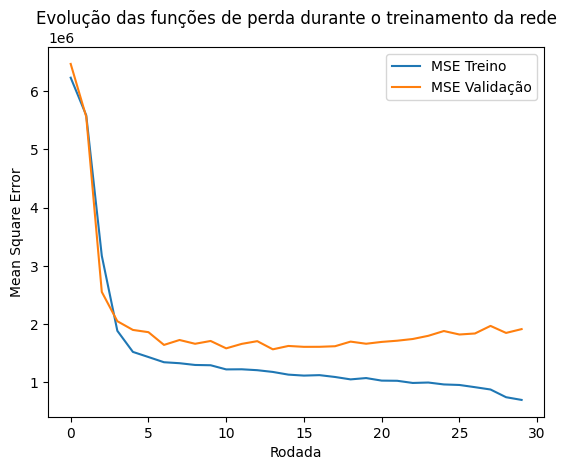

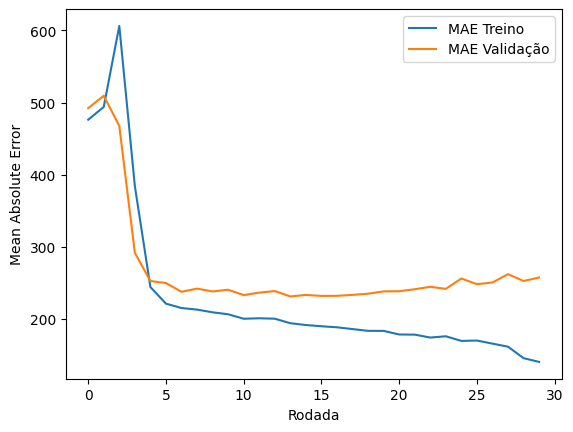

In [68]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure()
plt.title("Evolução das funções de perda durante o treinamento da rede")
plt.xlabel('Rodada')
plt.ylabel('Mean Square Error')
plt.plot(hist['epoch'], hist['mse'], label='MSE Treino')
plt.plot(hist['epoch'], hist['val_mse'], label = 'MSE Validação')
plt.legend()

plt.figure()
plt.xlabel('Rodada')
plt.ylabel('Mean Absolute Error')
plt.plot(hist['epoch'], hist['mae'], label='MAE Treino')
plt.plot(hist['epoch'], hist['val_mae'], label = 'MAE Validação')
plt.legend()

plt.show()